<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ecsm_sparc_full_model_reproduction_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ECSM SPARC full-model reproduction notebook

This notebook is designed for the paper release. It starts from the raw SPARC `Rotmod_LTG.zip` archive, rebuilds the ECSM finite-response rotation-curve fits, saves the processed CSV outputs, and then generates the paper figures with the Overleaf-ready file names.

**Input required**

- `Rotmod_LTG.zip` containing the SPARC `*_rotmod.dat` files.

**Main outputs**

- `data/simplified_ecsm_clean_summary_full.csv`
- `data/simplified_ecsm_curves_full.csv`
- `data/simplified_ecsm_paper_table_full.csv`
- `figures/ecsm_full_sample_fit_quality.png`
- `figures/ecsm_mond_acceleration_relation.png`
- `figures/ecsm_response_factor_vs_gbar.png`
- `figures/outer_memory_diagnostic_interpretation.png`
- `figures/bad_galaxy_gradient_activation_interpretation.png`
- `figures/bad_galaxy_abnormality_histograms.png`

This is the **full model reproduction notebook** for the paper: raw SPARC files → ECSM model outputs → paper figures.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

# ============================================================
# CELL 01 — SETUP
# ============================================================

import os
import re
import glob
import zipfile
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RNG_SEED = 7
rng = np.random.default_rng(RNG_SEED)

ROOT = Path(".").resolve()
DATA_DIR = ROOT / "data"
RAW_DIR = ROOT / "raw"
OUTDIR = ROOT / "ecsm_sparc_full_model_outputs"
FIGDIR = ROOT / "figures"

for d in [DATA_DIR, RAW_DIR, OUTDIR, FIGDIR]:
    d.mkdir(parents=True, exist_ok=True)

KPC_TO_M = 3.0856775814913673e19
KM2_TO_M2 = 1.0e6

# Parameter grids used in the paper-reproduction run.
A0_GRID = np.array([1.0e-10, 1.2e-10, 1.4e-10, 1.6e-10])
YD_GRID = np.array([0.4, 0.5, 0.6])
S_FLOOR_GRID = np.array([0.3, 0.5, 0.7])
Q_SAT_GRID = np.array([1.0, 2.0])
R_FRAC_GRID = np.array([0.05, 0.10, 0.20, 0.35, 0.50])
WIDTH_FRAC_GRID = np.array([0.03, 0.05, 0.08, 0.12])
LAMBDA_RELAX_GRID = np.array([0.0, 0.3, 0.7])
GAIN_GRID = np.array([0.85, 1.00, 1.15, 1.30])

GRID_SIZE = (
    len(A0_GRID) * len(YD_GRID) * len(S_FLOOR_GRID) * len(Q_SAT_GRID)
    * len(R_FRAC_GRID) * len(WIDTH_FRAC_GRID) * len(LAMBDA_RELAX_GRID)
    * len(GAIN_GRID)
)

print("=" * 70)
print("ECSM SPARC FULL-MODEL NOTEBOOK SETUP")
print("=" * 70)
print("Working directory:", ROOT)
print("Data directory   :", DATA_DIR)
print("Figure directory :", FIGDIR)
print("Random seed      :", RNG_SEED)
print("Grid size per galaxy:", GRID_SIZE)


ECSM SPARC FULL-MODEL NOTEBOOK SETUP
Working directory: /content
Data directory   : /content/data
Figure directory : /content/figures
Random seed      : 7
Grid size per galaxy: 17280


In [ ]:

# ============================================================
# CELL 02 — LOCATE OR UPLOAD RAW SPARC ROTMOD ZIP
# ============================================================

def find_rotmod_zip():
    candidates = []
    search_roots = [
        ROOT,
        DATA_DIR,
        RAW_DIR,
        Path("/content"),
        Path("/content/drive/MyDrive"),
    ]
    for root in search_roots:
        if root.exists():
            candidates += list(root.glob("**/Rotmod_LTG.zip"))
            candidates += list(root.glob("**/*Rotmod*LTG*.zip"))
            candidates += list(root.glob("**/*rotmod*.zip"))

    candidates = sorted(set(candidates), key=lambda p: (p.name != "Rotmod_LTG.zip", len(str(p))))
    return candidates[0] if candidates else None


rotmod_zip = find_rotmod_zip()

if rotmod_zip is None:
    try:
        from google.colab import files
        print("Raw SPARC Rotmod_LTG.zip not found. Please upload it now.")
        uploaded = files.upload()
        for fn in uploaded:
            if fn.lower().endswith(".zip") and "rotmod" in fn.lower():
                rotmod_zip = Path("/content") / fn
                break
    except Exception:
        pass

if rotmod_zip is None or not Path(rotmod_zip).exists():
    raise FileNotFoundError(
        "Could not find Rotmod_LTG.zip. Place it in ./data, ./raw, /content, or Drive."
    )

rotmod_zip = Path(rotmod_zip)
print("Using raw SPARC archive:", rotmod_zip)

extract_dir = RAW_DIR / "Rotmod_LTG"
if extract_dir.exists():
    shutil.rmtree(extract_dir)
extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(rotmod_zip, "r") as z:
    z.extractall(extract_dir)

rotmod_files = sorted(extract_dir.glob("**/*rotmod.dat"))
if len(rotmod_files) == 0:
    rotmod_files = sorted([p for p in extract_dir.glob("**/*") if p.name.lower().endswith("rotmod.dat")])

print("Rotmod files found:", len(rotmod_files))
print("First files:", [p.name for p in rotmod_files[:5]])


Using raw SPARC archive: /content/drive/MyDrive/Rotmod_LTG.zip
Rotmod files found: 175
First files: ['CamB_rotmod.dat', 'D512-2_rotmod.dat', 'D564-8_rotmod.dat', 'D631-7_rotmod.dat', 'DDO064_rotmod.dat']


In [ ]:

# ============================================================
# CELL 03 — PARSE SPARC ROTATION-CURVE FILES
# ============================================================

ROTMOD_COLS = ["Rad", "Vobs", "errV", "Vgas", "Vdisk", "Vbul", "SBdisk", "SBbul"]

def clean_galaxy_name(path):
    return Path(path).name.replace("_rotmod.dat", "")

def parse_rotmod_file(path):
    df = pd.read_csv(path, delim_whitespace=True, comment="#", header=None, names=ROTMOD_COLS, engine="python")
    for c in ROTMOD_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["Rad", "Vobs", "errV", "Vgas", "Vdisk"]).copy()
    df = df[(df["Rad"] > 0) & (df["errV"] > 0)].copy()
    df["Vbul"] = df["Vbul"].fillna(0.0)
    df["galaxy"] = clean_galaxy_name(path)
    return df[["galaxy"] + ROTMOD_COLS]

galaxies = []
failures = []

for p in rotmod_files:
    try:
        gdf = parse_rotmod_file(p)
        if len(gdf) >= 3:
            galaxies.append(gdf)
        else:
            failures.append((p.name, "too few valid rows"))
    except Exception as e:
        failures.append((p.name, repr(e)))

if not galaxies:
    raise RuntimeError("No usable SPARC rotmod tables were parsed.")

all_rot = pd.concat(galaxies, ignore_index=True)

print("=" * 70)
print("SPARC PARSE SUMMARY")
print("=" * 70)
print("Prepared galaxies:", all_rot["galaxy"].nunique())
print("Curve rows:", len(all_rot))
print("Parse failures:", len(failures))
if failures[:10]:
    print("First failures:", failures[:10])

display(all_rot.head())


SPARC PARSE SUMMARY
Prepared galaxies: 175
Curve rows: 3391
Parse failures: 0


,galaxy,Rad,Vobs,errV,Vgas,Vdisk,Vbul,SBdisk,SBbul
0,CamB,0.16,1.99,1.5,1.86,3.75,0.0,30.32,0.0
1,CamB,0.41,4.84,1.5,4.24,9.47,0.0,23.77,0.0
2,CamB,0.57,6.79,1.5,5.61,11.76,0.0,15.87,0.0
3,CamB,0.73,8.87,1.5,6.77,13.72,0.0,12.40,0.0
4,CamB,0.90,10.90,1.5,7.77,14.80,0.0,9.63,0.0


In [ ]:

# ============================================================
# CELL 04 — ECSM MODEL FUNCTIONS
# ============================================================

def signed_square(v):
    """SPARC gas terms can be formally negative. Preserve sign in squared contribution."""
    v = np.asarray(v, dtype=float)
    return np.sign(v) * v**2

def baryonic_velocity_squared(df, yd=0.5, yb=None):
    if yb is None:
        yb = yd
    vgas2 = signed_square(df["Vgas"].values)
    vdisk2 = df["Vdisk"].values**2
    vbul2 = df["Vbul"].values**2 if "Vbul" in df.columns else 0.0
    vbar2 = vgas2 + yd * vdisk2 + yb * vbul2
    return np.clip(vbar2, 1e-12, None)

def acceleration_from_v2_r(v2_km2_s2, r_kpc):
    return (np.asarray(v2_km2_s2) * KM2_TO_M2) / (np.asarray(r_kpc) * KPC_TO_M)

def simple_mond_acceleration(gbar, a0):
    gbar = np.clip(np.asarray(gbar, dtype=float), 1e-30, None)
    return 0.5 * (gbar + np.sqrt(gbar**2 + 4.0 * a0 * gbar))

def velocity_from_acceleration(g, r_kpc):
    v2 = np.asarray(g) * (np.asarray(r_kpc) * KPC_TO_M) / KM2_TO_M2
    return np.sqrt(np.clip(v2, 0.0, None))

def core_contrast_from_gbar(r, gbar):
    r = np.asarray(r)
    gbar = np.asarray(gbar)
    inner = gbar[r <= np.nanpercentile(r, 35)]
    outer = gbar[r >= np.nanpercentile(r, 65)]
    if len(inner) == 0 or len(outer) == 0:
        return 1.0
    med_inner = np.nanmedian(np.clip(inner, 1e-30, None))
    med_outer = np.nanmedian(np.clip(outer, 1e-30, None))
    return float(np.clip(med_inner / med_outer, 0.01, 1e4))

def ecsm_model_for_params(df, a0, yd, s_floor, q_sat, r_frac, width_frac, lambda_relax, gain):
    r = df["Rad"].values.astype(float)
    vbar2 = baryonic_velocity_squared(df, yd=yd)
    vbar = np.sqrt(vbar2)

    gbar = acceleration_from_v2_r(vbar2, r)
    graw = simple_mond_acceleration(gbar, a0)
    vraw = velocity_from_acceleration(graw, r)

    excess2 = np.clip(vraw**2 - vbar2, 0.0, None)

    D_core = core_contrast_from_gbar(r, gbar)
    stretch = 1.0 + lambda_relax * np.log1p(D_core)
    rmax = np.nanmax(r)

    r_act = np.clip(r_frac * rmax * stretch, 0.02 * rmax, 0.95 * rmax)
    width = np.clip(width_frac * rmax * (1.0 + 0.15 * lambda_relax * np.log1p(D_core)), 1e-6, None)

    W = 0.5 * (1.0 + np.tanh((r - r_act) / width))
    S = s_floor + (1.0 - s_floor) * np.clip(W, 0, 1)**q_sat

    vmodel2 = vbar2 + gain * S * excess2
    vmodel = np.sqrt(np.clip(vmodel2, 0.0, None))

    return {
        "R": r,
        "Vbar": vbar,
        "Vraw_chi_mond": vraw,
        "Vmodel": vmodel,
        "gbar": gbar,
        "graw": graw,
        "gecsm": acceleration_from_v2_r(vmodel2, r),
        "D_core": D_core,
        "relax_stretch": stretch,
        "r_act": r_act,
        "width": width,
        "W": W,
        "S": S,
    }

def red_chi2(vobs, vmod, err, n_params=7):
    ok = np.isfinite(vobs) & np.isfinite(vmod) & np.isfinite(err) & (err > 0)
    if ok.sum() == 0:
        return np.inf, np.inf, 0
    chi2 = float(np.sum(((vobs[ok] - vmod[ok]) / err[ok])**2))
    dof = max(int(ok.sum() - n_params), 1)
    return chi2 / dof, chi2, dof

def fit_galaxy(df):
    vobs = df["Vobs"].values.astype(float)
    err = df["errV"].values.astype(float)

    best = None
    best_model = None

    best_baryon = (np.inf, None)
    for yd in YD_GRID:
        vbar = np.sqrt(baryonic_velocity_squared(df, yd=yd))
        rc2, chi2, dof = red_chi2(vobs, vbar, err, n_params=1)
        if rc2 < best_baryon[0]:
            best_baryon = (rc2, yd)

    best_raw = (np.inf, None, None)
    for a0 in A0_GRID:
        for yd in YD_GRID:
            m = ecsm_model_for_params(df, a0, yd, 1.0, 1.0, 0.05, 0.03, 0.0, 1.0)
            rc2, chi2, dof = red_chi2(vobs, m["Vraw_chi_mond"], err, n_params=2)
            if rc2 < best_raw[0]:
                best_raw = (rc2, a0, yd)

    for a0 in A0_GRID:
        for yd in YD_GRID:
            for s_floor in S_FLOOR_GRID:
                for q_sat in Q_SAT_GRID:
                    for r_frac in R_FRAC_GRID:
                        for width_frac in WIDTH_FRAC_GRID:
                            for lambda_relax in LAMBDA_RELAX_GRID:
                                for gain in GAIN_GRID:
                                    m = ecsm_model_for_params(
                                        df, a0, yd, s_floor, q_sat, r_frac, width_frac, lambda_relax, gain
                                    )
                                    rc2, chi2, dof = red_chi2(vobs, m["Vmodel"], err, n_params=8)
                                    if best is None or rc2 < best["red_chi2"]:
                                        best = dict(
                                            galaxy=df["galaxy"].iloc[0],
                                            N=len(df),
                                            red_chi2=rc2,
                                            chi2=chi2,
                                            dof=dof,
                                            chi2_raw_chi_mond=best_raw[0],
                                            chi2_baryon_only=best_baryon[0],
                                            improvement_vs_raw=best_raw[0] - rc2,
                                            improvement_vs_baryon=best_baryon[0] - rc2,
                                            a0=a0,
                                            Yd=yd,
                                            D_core=m["D_core"],
                                            lambda_relax=lambda_relax,
                                            relax_stretch=m["relax_stretch"],
                                            L_relax=m["r_act"],
                                            r_frac=r_frac,
                                            width_frac_base=width_frac,
                                            gain=gain,
                                            a_sat=a0,
                                            q_sat=q_sat,
                                            S_floor=s_floor,
                                            median_W=float(np.nanmedian(m["W"])),
                                            median_S=float(np.nanmedian(m["S"])),
                                        )
                                        best_model = m

    curve = df.copy()
    curve["Vbar"] = best_model["Vbar"]
    curve["Vraw_chi_mond"] = best_model["Vraw_chi_mond"]
    curve["Vmodel"] = best_model["Vmodel"]
    curve["gbar"] = best_model["gbar"]
    curve["graw"] = best_model["graw"]
    curve["gecsm"] = best_model["gecsm"]
    curve["W_response"] = best_model["W"]
    curve["S_response"] = best_model["S"]

    return best, curve

print("Model functions ready.")


Model functions ready.


In [ ]:

# ============================================================
# CELL 05 — RUN FULL 175-GALAXY ECSM FIT
# ============================================================

RUN_LIMIT = None  # set to e.g. 10 for quick debugging; None runs all galaxies

summary_rows = []
curve_rows = []
fit_failures = []

galaxy_names = sorted(all_rot["galaxy"].unique())
if RUN_LIMIT is not None:
    galaxy_names = galaxy_names[:RUN_LIMIT]

print("=" * 70)
print("RUNNING ECSM FINITE-RESPONSE FULL-SAMPLE MODEL")
print("=" * 70)
print("Galaxies to test:", len(galaxy_names))

for idx, gal in enumerate(galaxy_names, 1):
    print(f"[{idx}/{len(galaxy_names)}] {gal}")
    gdf = all_rot[all_rot["galaxy"] == gal].copy().sort_values("Rad")
    try:
        summary_row, curve_df = fit_galaxy(gdf)
        summary_rows.append(summary_row)
        curve_rows.append(curve_df)
    except Exception as e:
        fit_failures.append({"galaxy": gal, "error": repr(e)})
        print("  FAILED:", repr(e))

summary = pd.DataFrame(summary_rows)
curves = pd.concat(curve_rows, ignore_index=True) if curve_rows else pd.DataFrame()
failures_df = pd.DataFrame(fit_failures)

if len(summary):
    summary = summary.sort_values("red_chi2").reset_index(drop=True)

summary_path = DATA_DIR / "simplified_ecsm_clean_summary_full.csv"
curves_path = DATA_DIR / "simplified_ecsm_curves_full.csv"
paper_table_path = DATA_DIR / "simplified_ecsm_paper_table_full.csv"
failures_path = DATA_DIR / "simplified_ecsm_failures.csv"

summary.to_csv(summary_path, index=False)
curves.to_csv(curves_path, index=False)
summary.to_csv(paper_table_path, index=False)
failures_df.to_csv(failures_path, index=False)

print("\n" + "=" * 70)
print("FULL MODEL RUN COMPLETE")
print("=" * 70)
print("Successful fits:", len(summary))
print("Curve rows:", len(curves))
print("Failures:", len(failures_df))
print("Saved:")
print(summary_path)
print(curves_path)
print(paper_table_path)
print(failures_path)

display(summary.head(20))


RUNNING ECSM FINITE-RESPONSE FULL-SAMPLE MODEL
Galaxies to test: 175
[1/175] CamB
[2/175] D512-2
[3/175] D564-8
[4/175] D631-7
[5/175] DDO064
[6/175] DDO154
[7/175] DDO161
[8/175] DDO168
[9/175] DDO170
[10/175] ESO079-G014
[11/175] ESO116-G012
[12/175] ESO444-G084
[13/175] ESO563-G021
[14/175] F561-1
[15/175] F563-1
[16/175] F563-V1
[17/175] F563-V2
[18/175] F565-V2
[19/175] F567-2
[20/175] F568-1
[21/175] F568-3
[22/175] F568-V1
[23/175] F571-8
[24/175] F571-V1
[25/175] F574-1
[26/175] F574-2
[27/175] F579-V1
[28/175] F583-1
[29/175] F583-4
[30/175] IC2574
[31/175] IC4202
[32/175] KK98-251
[33/175] NGC0024
[34/175] NGC0055
[35/175] NGC0100
[36/175] NGC0247
[37/175] NGC0289
[38/175] NGC0300
[39/175] NGC0801
[40/175] NGC0891
[41/175] NGC1003
[42/175] NGC1090
[43/175] NGC1705
[44/175] NGC2366
[45/175] NGC2403
[46/175] NGC2683
[47/175] NGC2841
[48/175] NGC2903
[49/175] NGC2915
[50/175] NGC2955
[51/175] NGC2976
[52/175] NGC2998
[53/175] NGC3109
[54/175] NGC3198
[55/175] NGC3521
[56/175] NG

,galaxy,N,red_chi2,chi2,dof,chi2_raw_chi_mond,chi2_baryon_only,improvement_vs_raw,improvement_vs_baryon,a0,...,relax_stretch,L_relax,r_frac,width_frac_base,gain,a_sat,q_sat,S_floor,median_W,median_S
0,UGC07232,4,0.034072,0.034072,1,2.838220,20.294827,2.804147,20.260755,1.400000e-10,...,1.565097,0.641690,0.50,0.12,1.30,1.400000e-10,1.0,0.3,0.206315,0.444421
1,UGC02023,5,0.077709,0.077709,1,2.245509,2.988372,2.167800,2.910663,1.000000e-10,...,1.470547,2.779333,0.50,0.12,0.85,1.000000e-10,1.0,0.3,0.109323,0.376526
2,NGC5005,18,0.081706,0.817062,10,0.074442,1.141449,-0.007264,1.059743,1.600000e-10,...,1.587633,1.821015,0.10,0.03,0.85,1.600000e-10,2.0,0.5,0.999999,0.999999
3,UGC07603,12,0.121622,0.486489,4,2.431246,118.780851,2.309624,118.659228,1.400000e-10,...,1.474987,0.606220,0.10,0.12,1.30,1.400000e-10,2.0,0.3,0.997310,0.996241
4,UGC01281,25,0.181789,3.090412,17,0.242989,23.707009,0.061200,23.525220,1.000000e-10,...,1.000000,0.499000,0.10,0.12,1.15,1.000000e-10,2.0,0.3,0.991390,0.987998
5,UGCA444,36,0.242758,6.797226,28,1.272508,12.831461,1.029750,12.588703,1.200000e-10,...,1.403880,1.839082,0.50,0.12,0.85,1.200000e-10,2.0,0.7,0.056038,0.700978
6,UGC06614,13,0.274669,1.373345,5,0.915027,30.745761,0.640358,30.471092,1.200000e-10,...,1.000000,22.606500,0.35,0.05,0.85,1.200000e-10,2.0,0.5,0.014203,0.500101
7,NGC0100,21,0.275632,3.583214,13,1.414903,45.667200,1.139272,45.391568,1.200000e-10,...,1.415977,2.724340,0.20,0.12,1.15,1.200000e-10,1.0,0.5,0.966708,0.983354
8,NGC3109,25,0.289856,4.927552,17,4.932765,150.028907,4.642909,149.739051,1.600000e-10,...,1.000000,2.257500,0.35,0.12,1.15,1.600000e-10,1.0,0.5,0.943906,0.971953
9,NGC3521,41,0.296854,9.796175,33,0.554260,9.199710,0.257406,8.902856,1.000000e-10,...,1.000000,6.209000,0.35,0.08,1.15,1.000000e-10,2.0,0.3,0.039792,0.301108


In [ ]:

# ============================================================
# CELL 06 — PAPER METRICS
# ============================================================

def safe_fraction(mask):
    mask = pd.Series(mask).dropna()
    return float(mask.mean()) if len(mask) else np.nan

metrics = {
    "N_galaxies": int(summary["galaxy"].nunique()),
    "curve_rows": int(len(curves)),
    "median_red_chi2": float(np.nanmedian(summary["red_chi2"])),
    "good_fit_frac_red_chi2_lt_3": safe_fraction(summary["red_chi2"] < 3),
    "very_good_fit_frac_red_chi2_lt_2": safe_fraction(summary["red_chi2"] < 2),
    "excellent_fit_frac_red_chi2_lt_1": safe_fraction(summary["red_chi2"] < 1),
    "median_baryon_red_chi2": float(np.nanmedian(summary["chi2_baryon_only"])),
    "median_raw_mond_red_chi2": float(np.nanmedian(summary["chi2_raw_chi_mond"])),
    "fraction_ecsm_beats_raw_mond": safe_fraction(summary["red_chi2"] < summary["chi2_raw_chi_mond"]),
    "fraction_ecsm_beats_baryon": safe_fraction(summary["red_chi2"] < summary["chi2_baryon_only"]),
}

metrics_df = pd.DataFrame([metrics])
metrics_path = DATA_DIR / "paper_metrics_summary.csv"
metrics_df.to_csv(metrics_path, index=False)

print("=" * 70)
print("PAPER METRICS")
print("=" * 70)
for k, v in metrics.items():
    print(f"{k}: {v}")

print("Saved:", metrics_path)
display(metrics_df)


PAPER METRICS
N_galaxies: 175
curve_rows: 3391
median_red_chi2: 4.871327163750635
good_fit_frac_red_chi2_lt_3: 0.37714285714285717
very_good_fit_frac_red_chi2_lt_2: 0.2914285714285714
excellent_fit_frac_red_chi2_lt_1: 0.19428571428571428
median_baryon_red_chi2: 75.18411345663957
median_raw_mond_red_chi2: 5.352795317751862
fraction_ecsm_beats_raw_mond: 0.5828571428571429
fraction_ecsm_beats_baryon: 0.9085714285714286
Saved: /content/data/paper_metrics_summary.csv


,N_galaxies,curve_rows,median_red_chi2,good_fit_frac_red_chi2_lt_3,very_good_fit_frac_red_chi2_lt_2,excellent_fit_frac_red_chi2_lt_1,median_baryon_red_chi2,median_raw_mond_red_chi2,fraction_ecsm_beats_raw_mond,fraction_ecsm_beats_baryon
0,175,3391,4.871327,0.377143,0.291429,0.194286,75.184113,5.352795,0.582857,0.908571


In [ ]:

# ============================================================
# CELL 07 — ACCELERATION-SPACE COMPARISON
# ============================================================

acc = curves.copy()
acc = acc[(acc["Rad"] > 0) & (acc["Vobs"] > 0) & (acc["Vbar"] > 0) & (acc["Vmodel"] > 0)].copy()

acc["gobs"] = acceleration_from_v2_r(acc["Vobs"].values**2, acc["Rad"].values)
acc["gbar_calc"] = acceleration_from_v2_r(acc["Vbar"].values**2, acc["Rad"].values)
acc["gecsm_calc"] = acceleration_from_v2_r(acc["Vmodel"].values**2, acc["Rad"].values)
acc["graw_calc"] = acceleration_from_v2_r(acc["Vraw_chi_mond"].values**2, acc["Rad"].values)
acc["gdeep_mond"] = np.sqrt(1.2e-10 * np.clip(acc["gbar_calc"], 1e-30, None))
acc["gsimple_mond"] = simple_mond_acceleration(acc["gbar_calc"].values, 1.2e-10)

def log_metrics(gmodel, gobs):
    ok = np.isfinite(gmodel) & np.isfinite(gobs) & (gmodel > 0) & (gobs > 0)
    d = np.log10(gmodel[ok]) - np.log10(gobs[ok])
    return float(np.sqrt(np.mean(d**2))), float(np.median(np.abs(d)))

rows = []
for name, col in [
    ("Baryon only", "gbar_calc"),
    ("Deep-MOND sqrt(a0 gbar)", "gdeep_mond"),
    ("Simple MOND interpolation", "gsimple_mond"),
    ("ECSM fitted response", "gecsm_calc"),
]:
    rmse, medabs = log_metrics(acc[col].values, acc["gobs"].values)
    rows.append({"model": name, "log10_RMSE_vs_gobs": rmse, "median_abs_log10_error": medabs})

global_accel_metrics = pd.DataFrame(rows).sort_values("log10_RMSE_vs_gobs").reset_index(drop=True)
global_accel_path = DATA_DIR / "global_acceleration_metrics.csv"
global_accel_metrics.to_csv(global_accel_path, index=False)

gal_rows = []
for gal, g in acc.groupby("galaxy"):
    if len(g) < 3:
        continue
    rb, mb = log_metrics(g["gbar_calc"].values, g["gobs"].values)
    rd, md = log_metrics(g["gdeep_mond"].values, g["gobs"].values)
    rs, ms = log_metrics(g["gsimple_mond"].values, g["gobs"].values)
    re, me = log_metrics(g["gecsm_calc"].values, g["gobs"].values)
    gal_rows.append({
        "galaxy": gal,
        "N": len(g),
        "logRMSE_baryon": rb,
        "logRMSE_mond_deep": rd,
        "logRMSE_mond_simple": rs,
        "logRMSE_ecsm": re,
        "ecsm_beats_mond_simple": re < rs,
        "ecsm_beats_baryon": re < rb,
        "median_gbar": float(np.median(g["gbar_calc"])),
        "median_gobs": float(np.median(g["gobs"])),
        "median_gecsm": float(np.median(g["gecsm_calc"])),
    })

galaxy_accel_metrics = pd.DataFrame(gal_rows)
galaxy_accel_path = DATA_DIR / "galaxy_level_acceleration_metrics.csv"
galaxy_accel_metrics.to_csv(galaxy_accel_path, index=False)

print("=" * 70)
print("GLOBAL DYNAMICAL COMPARISON")
print("=" * 70)
display(global_accel_metrics)

print("\nGalaxy-level summary:")
print("Galaxies:", len(galaxy_accel_metrics))
print("Fraction ECSM beats simple MOND:", galaxy_accel_metrics["ecsm_beats_mond_simple"].mean())
print("Fraction ECSM beats baryon:", galaxy_accel_metrics["ecsm_beats_baryon"].mean())
print("Median ECSM logRMSE:", galaxy_accel_metrics["logRMSE_ecsm"].median())
print("Median simple MOND logRMSE:", galaxy_accel_metrics["logRMSE_mond_simple"].median())
print("Median baryon logRMSE:", galaxy_accel_metrics["logRMSE_baryon"].median())

print("Saved:")
print(global_accel_path)
print(galaxy_accel_path)


GLOBAL DYNAMICAL COMPARISON


,model,log10_RMSE_vs_gobs,median_abs_log10_error
0,ECSM fitted response,0.182543,0.027333
1,Simple MOND interpolation,0.227567,0.078698
2,Deep-MOND sqrt(a0 gbar),0.293897,0.149784
3,Baryon only,0.602574,0.436353



Galaxy-level summary:
Galaxies: 175
Fraction ECSM beats simple MOND: 0.92
Fraction ECSM beats baryon: 0.9485714285714286
Median ECSM logRMSE: 0.07240881168699856
Median simple MOND logRMSE: 0.1424592382211124
Median baryon logRMSE: 0.49395847553833777
Saved:
/content/data/global_acceleration_metrics.csv
/content/data/galaxy_level_acceleration_metrics.csv


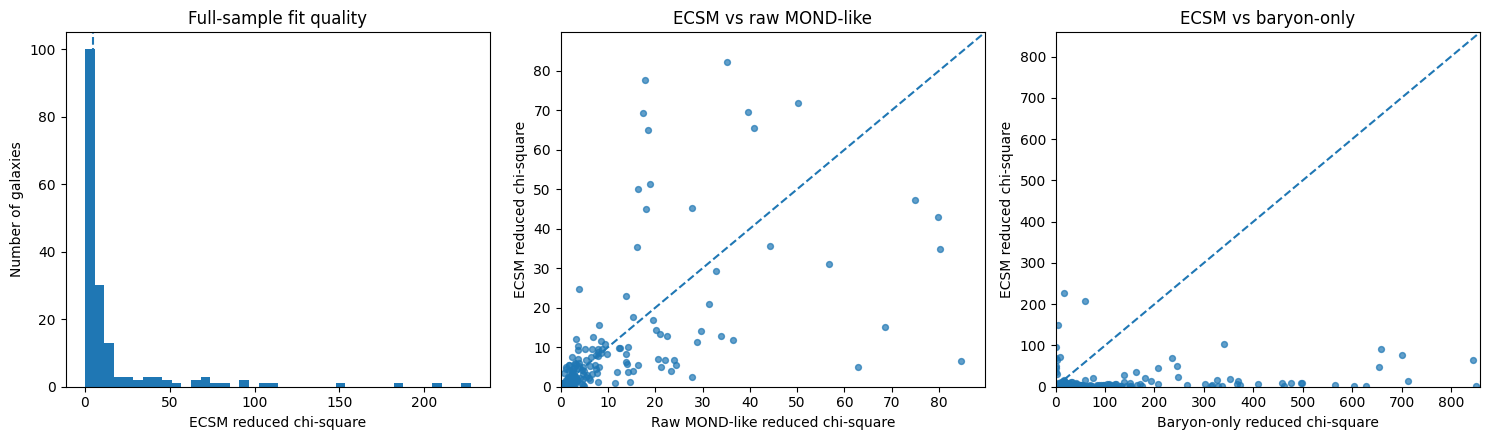

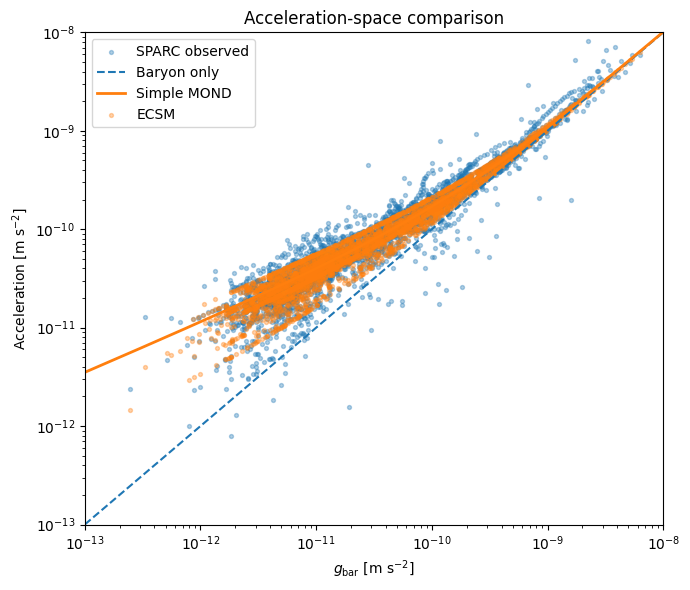

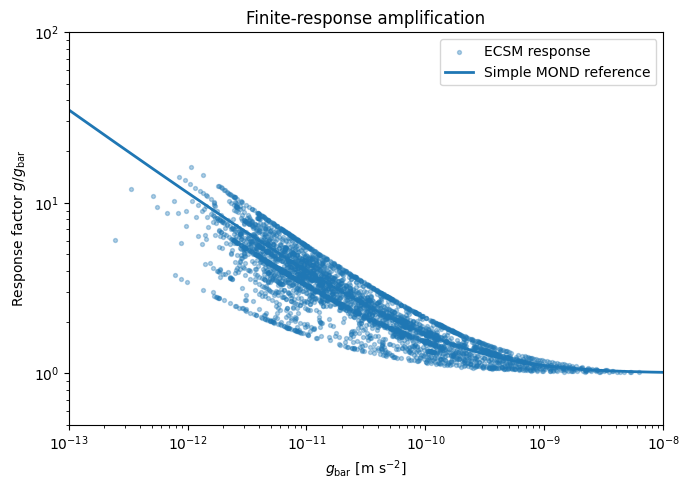

Saved figures:
/content/figures/ecsm_full_sample_fit_quality.png
/content/figures/ecsm_mond_acceleration_relation.png
/content/figures/ecsm_response_factor_vs_gbar.png

Figure 2/3 publication clipping summary:
Acceleration plot rows used: 3386
Response plot rows used: 3389


In [15]:
# ============================================================
# CELL 08 — PAPER FIGURES: FULL SAMPLE + ACCELERATION RELATION
# ============================================================

# -----------------------------
# Figure 1: fit-quality summary
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].hist(summary["red_chi2"].replace([np.inf, -np.inf], np.nan).dropna(), bins=40)
axes[0].axvline(np.nanmedian(summary["red_chi2"]), linestyle="--")
axes[0].set_xlabel("ECSM reduced chi-square")
axes[0].set_ylabel("Number of galaxies")
axes[0].set_title("Full-sample fit quality")

axes[1].scatter(summary["chi2_raw_chi_mond"], summary["red_chi2"], s=18, alpha=0.7)
mx = np.nanmax([summary["chi2_raw_chi_mond"].quantile(0.95), summary["red_chi2"].quantile(0.95)])
axes[1].plot([0, mx], [0, mx], linestyle="--")
axes[1].set_xlim(0, mx)
axes[1].set_ylim(0, mx)
axes[1].set_xlabel("Raw MOND-like reduced chi-square")
axes[1].set_ylabel("ECSM reduced chi-square")
axes[1].set_title("ECSM vs raw MOND-like")

axes[2].scatter(summary["chi2_baryon_only"], summary["red_chi2"], s=18, alpha=0.7)
mx = np.nanmax([summary["chi2_baryon_only"].quantile(0.90), summary["red_chi2"].quantile(0.95)])
axes[2].plot([0, mx], [0, mx], linestyle="--")
axes[2].set_xlim(0, mx)
axes[2].set_ylim(0, mx)
axes[2].set_xlabel("Baryon-only reduced chi-square")
axes[2].set_ylabel("ECSM reduced chi-square")
axes[2].set_title("ECSM vs baryon-only")

plt.tight_layout()
fig1_path = FIGDIR / "ecsm_full_sample_fit_quality.png"
plt.savefig(fig1_path, dpi=220)
plt.show()


# -----------------------------
# Figure 2: acceleration-space comparison
# Clip numerical floor artefacts for publication display.
# This does not change the model or metrics.
# -----------------------------
acc_plot = acc.copy()

for col in ["gbar_calc", "gobs", "gecsm_calc", "gsimple_mond"]:
    acc_plot[col] = pd.to_numeric(acc_plot[col], errors="coerce")

acc_plot = acc_plot.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["gbar_calc", "gobs", "gecsm_calc", "gsimple_mond"]
)

acc_plot = acc_plot[
    (acc_plot["gbar_calc"] > 1e-13) &
    (acc_plot["gbar_calc"] < 1e-8) &
    (acc_plot["gobs"] > 1e-13) &
    (acc_plot["gobs"] < 1e-8) &
    (acc_plot["gecsm_calc"] > 1e-13) &
    (acc_plot["gecsm_calc"] < 1e-8) &
    (acc_plot["gsimple_mond"] > 1e-13) &
    (acc_plot["gsimple_mond"] < 1e-8)
].copy()

plot_acc = acc_plot.sample(min(len(acc_plot), 4000), random_state=RNG_SEED) if len(acc_plot) > 4000 else acc_plot

gbar_line = np.logspace(-13, -8, 300)
simple_mond_line = simple_mond_acceleration(gbar_line, 1.2e-10)

plt.figure(figsize=(7, 6))
plt.scatter(plot_acc["gbar_calc"], plot_acc["gobs"], s=8, alpha=0.35, label="SPARC observed")
plt.plot(gbar_line, gbar_line, linestyle="--", label="Baryon only")
plt.plot(gbar_line, simple_mond_line, linewidth=2, label="Simple MOND")
plt.scatter(plot_acc["gbar_calc"], plot_acc["gecsm_calc"], s=8, alpha=0.35, label="ECSM")

plt.xscale("log")
plt.yscale("log")
plt.xlim(1e-13, 1e-8)
plt.ylim(1e-13, 1e-8)
plt.xlabel(r"$g_{\rm bar}$ [m s$^{-2}$]")
plt.ylabel(r"Acceleration [m s$^{-2}$]")
plt.title("Acceleration-space comparison")
plt.legend()
plt.tight_layout()

fig2_path = FIGDIR / "ecsm_mond_acceleration_relation.png"
plt.savefig(fig2_path, dpi=220)
plt.show()


# -----------------------------
# Figure 3: finite-response amplification
# Clip numerical floor artefacts for publication display.
# This does not change the model or metrics.
# -----------------------------
resp = acc.copy()

for col in ["gbar_calc", "gecsm_calc", "gsimple_mond"]:
    resp[col] = pd.to_numeric(resp[col], errors="coerce")

resp = resp.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["gbar_calc", "gecsm_calc", "gsimple_mond"]
)

resp["R_ecsm"] = resp["gecsm_calc"] / resp["gbar_calc"]
resp["R_mond"] = resp["gsimple_mond"] / resp["gbar_calc"]

resp_plot = resp[
    (resp["gbar_calc"] > 1e-13) &
    (resp["gbar_calc"] < 1e-8) &
    (resp["R_ecsm"] > 0.5) &
    (resp["R_ecsm"] < 100) &
    np.isfinite(resp["R_ecsm"])
].copy()

xgrid = np.logspace(-13, -8, 300)
mond_response = simple_mond_acceleration(xgrid, 1.2e-10) / xgrid

plt.figure(figsize=(7, 5))
plt.scatter(resp_plot["gbar_calc"], resp_plot["R_ecsm"], s=8, alpha=0.35, label="ECSM response")
plt.plot(xgrid, mond_response, linewidth=2, label="Simple MOND reference")

plt.xscale("log")
plt.yscale("log")
plt.xlim(1e-13, 1e-8)
plt.ylim(0.5, 100)
plt.xlabel(r"$g_{\rm bar}$ [m s$^{-2}$]")
plt.ylabel(r"Response factor $g/g_{\rm bar}$")
plt.title("Finite-response amplification")
plt.legend()
plt.tight_layout()

fig3_path = FIGDIR / "ecsm_response_factor_vs_gbar.png"
plt.savefig(fig3_path, dpi=220)
plt.show()

print("Saved figures:")
print(fig1_path)
print(fig2_path)
print(fig3_path)

print("\nFigure 2/3 publication clipping summary:")
print("Acceleration plot rows used:", len(acc_plot))
print("Response plot rows used:", len(resp_plot))

In [ ]:

# ============================================================
# CELL 09 — WORST-GALAXY DIAGNOSTICS
# ============================================================

worst = summary.sort_values("red_chi2", ascending=False).head(5)["galaxy"].tolist()
print("Worst galaxies selected:", worst)

ab_rows = []
for gal, g in curves.groupby("galaxy"):
    g = g.sort_values("Rad").copy()
    if len(g) < 3:
        continue
    resid = g["Vobs"].values - g["Vmodel"].values
    pull = resid / np.clip(g["errV"].values, 1e-9, None)
    r = g["Rad"].values
    vobs = g["Vobs"].values
    vbar = g["Vbar"].values

    n = len(g)
    i1 = min(n-1, max(1, n//3))
    i2 = max(0, int(0.7*n)-1)
    inner_rise = (vobs[i1] - vobs[0]) / max(r[i1] - r[0], 1e-9)
    outer_slope = (vobs[-1] - vobs[i2]) / max(r[-1] - r[i2], 1e-9)

    dv = np.diff(vobs)
    wiggle_frac = float(np.nanstd(dv) / max(np.nanmax(vobs), 1e-9)) if len(dv) else 0.0
    sign_changes = int(np.sum(np.diff(np.sign(pull)) != 0)) if len(pull) > 1 else 0

    red_val = summary.loc[summary["galaxy"] == gal, "red_chi2"]
    red_val = float(red_val.iloc[0]) if len(red_val) else np.nan

    ab_rows.append({
        "galaxy_clean": gal,
        "red_chi2": red_val,
        "N_curve": n,
        "Rmax": float(np.nanmax(r)),
        "Vmax": float(np.nanmax(vobs)),
        "Vlast_over_Vmax": float(vobs[-1] / max(np.nanmax(vobs), 1e-9)),
        "median_errV": float(np.nanmedian(g["errV"])),
        "median_frac_errV": float(np.nanmedian(g["errV"] / np.clip(vobs, 1e-9, None))),
        "max_frac_errV": float(np.nanmax(g["errV"] / np.clip(vobs, 1e-9, None))),
        "inner_rise": float(inner_rise),
        "outer_slope": float(outer_slope),
        "wiggle_frac": float(wiggle_frac),
        "abs_median_pull": float(np.nanmedian(np.abs(pull))),
        "rms_pull": float(np.sqrt(np.nanmean(pull**2))),
        "residual_bias": float(np.nanmedian(resid)),
        "residual_span": float(np.nanmax(resid) - np.nanmin(resid)),
        "residual_sign_changes": sign_changes,
        "Vbar_frac_med": float(np.nanmedian(vbar / np.clip(vobs, 1e-9, None))),
    })

abnormality = pd.DataFrame(ab_rows)
score_cols = ["rms_pull", "abs_median_pull", "residual_span", "wiggle_frac", "max_frac_errV"]
for c in score_cols:
    abnormality[c + "_pct"] = abnormality[c].rank(pct=True)
abnormality["abnormality_score"] = abnormality[[c + "_pct" for c in score_cols]].mean(axis=1)

abnormality = abnormality.sort_values("red_chi2", ascending=False).reset_index(drop=True)
bad_abnormality_report = abnormality[abnormality["galaxy_clean"].isin(worst)].copy()

abnormality_path = DATA_DIR / "full_galaxy_abnormality_ranked.csv"
bad_ab_path = DATA_DIR / "bad_galaxy_abnormality_report.csv"
abnormality.to_csv(abnormality_path, index=False)
bad_abnormality_report.to_csv(bad_ab_path, index=False)

print("Saved:")
print(abnormality_path)
print(bad_ab_path)
display(bad_abnormality_report)


Worst galaxies selected: ['UGC02455', 'UGC06973', 'UGC05764', 'CamB', 'UGC00128']
Saved:
/content/data/full_galaxy_abnormality_ranked.csv
/content/data/bad_galaxy_abnormality_report.csv


,galaxy_clean,red_chi2,N_curve,Rmax,Vmax,Vlast_over_Vmax,median_errV,median_frac_errV,max_frac_errV,inner_rise,...,residual_bias,residual_span,residual_sign_changes,Vbar_frac_med,rms_pull_pct,abs_median_pull_pct,residual_span_pct,wiggle_frac_pct,max_frac_errV_pct,abnormality_score
0,UGC02455,227.422578,8,4.03,61.0,1.000000,3.64,0.101699,0.215385,11.188119,...,-18.662381,17.252250,0,1.424177,0.982857,0.994286,0.451429,0.228571,0.565714,0.644571
1,UGC06973,207.741363,9,7.85,180.0,1.000000,4.80,0.028070,0.057062,0.000000,...,1.610482,73.209390,3,0.821228,0.965714,0.817143,0.942857,0.040000,0.051429,0.563429
2,UGC05764,184.000537,10,3.62,55.8,0.894265,0.96,0.020719,0.092774,24.678899,...,0.933242,18.546266,1,0.370519,0.994286,0.988571,0.491429,0.862857,0.188571,0.705143
3,CamB,149.811998,9,1.79,20.1,1.000000,1.50,0.137615,0.753769,12.070175,...,-6.239678,5.048504,0,1.116061,0.931429,0.982857,0.091429,0.177143,0.920000,0.620571
4,UGC00128,112.568041,22,53.75,134.0,0.932836,1.25,0.010437,0.551320,5.263459,...,-4.750518,33.461000,2,0.413498,1.000000,1.000000,0.737143,0.794286,0.868571,0.880000


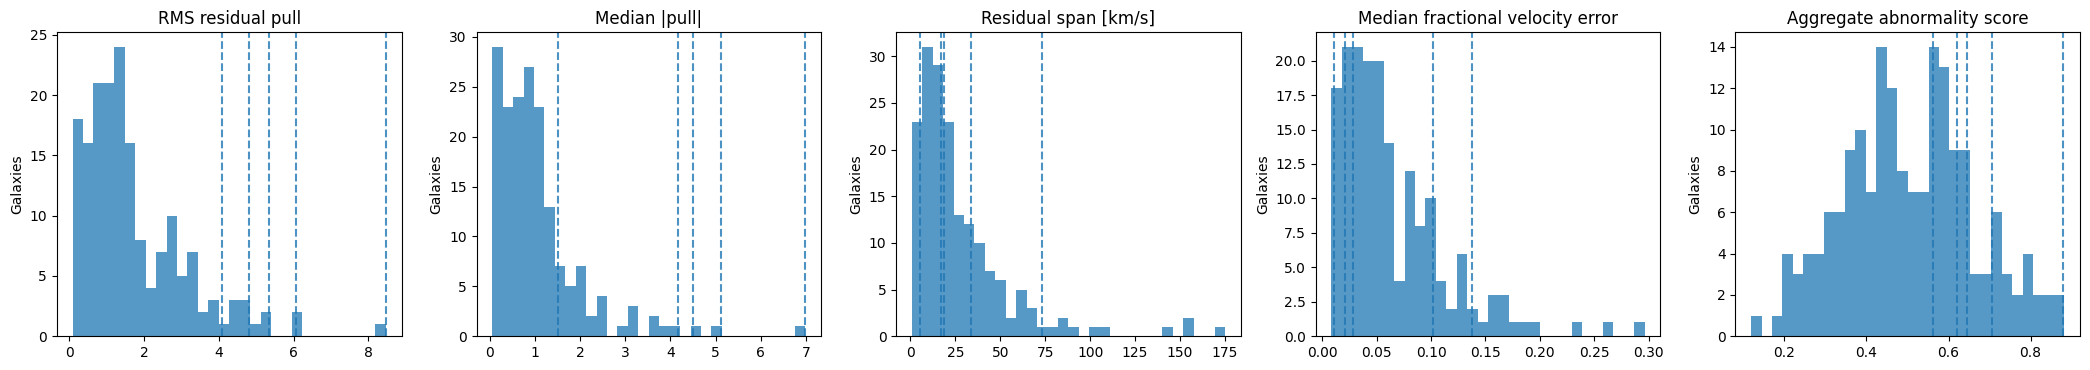

Saved: /content/figures/bad_galaxy_abnormality_histograms.png


In [ ]:

# ============================================================
# CELL 10 — PAPER FIGURE: BAD-GALAXY ABNORMALITY HISTOGRAMS
# ============================================================

features = [
    ("rms_pull", "RMS residual pull"),
    ("abs_median_pull", "Median |pull|"),
    ("residual_span", "Residual span [km/s]"),
    ("median_frac_errV", "Median fractional velocity error"),
    ("abnormality_score", "Aggregate abnormality score"),
]

fig, axes = plt.subplots(1, len(features), figsize=(4.2*len(features), 3.8))

for ax, (col, title) in zip(axes, features):
    ax.hist(abnormality[col].replace([np.inf, -np.inf], np.nan).dropna(), bins=30, alpha=0.75)
    vals = bad_abnormality_report[col].values
    for v in vals:
        ax.axvline(v, linestyle="--", alpha=0.8)
    ax.set_title(title)
    ax.set_ylabel("Galaxies")

plt.tight_layout()
fig_path = FIGDIR / "bad_galaxy_abnormality_histograms.png"
plt.savefig(fig_path, dpi=220)
plt.show()

print("Saved:", fig_path)


OUTER-MEMORY DIAGNOSTIC
Fraction improved: 0.8
Median improvement: 7.060660960037048


,galaxy,N,base_red_chi2,memory_red_chi2,improvement,A_memory,mu_memory,r_mem,r_mem_over_Rmax,M_outer_median,M_inner_median
0,UGC02455,8,32.488940,25.428279,7.060661,0.9,12.0,0.6045,0.15,0.100415,0.234399
1,UGC06973,9,25.967670,34.623560,-8.655890,0.0,0.5,1.1775,0.15,1.000000,1.000000
2,UGC05764,10,40.889008,37.175412,3.713596,0.5,12.0,2.8960,0.80,0.748343,0.998747
3,CamB,9,18.726500,6.390001,12.336499,0.9,12.0,0.2685,0.15,0.101525,0.278271
4,UGC00128,22,75.045361,56.238530,18.806830,0.2,12.0,32.2500,0.60,0.823368,0.996842


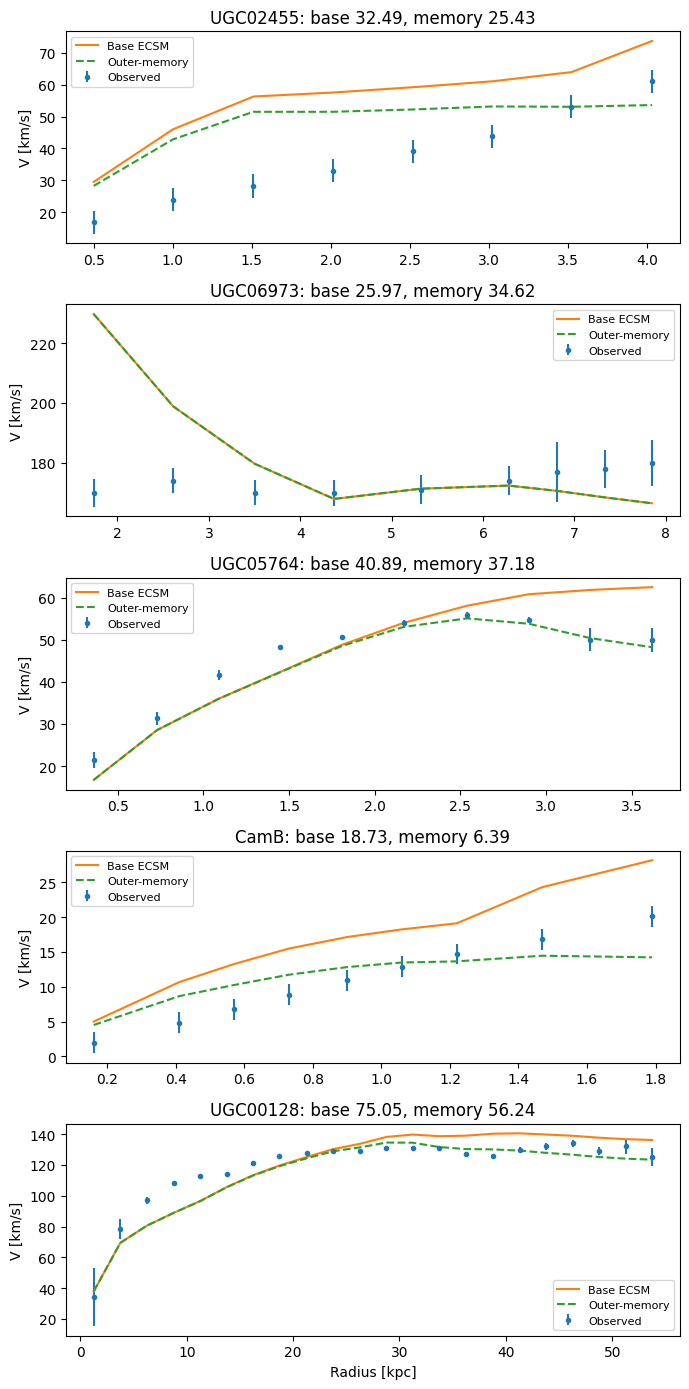

Saved:
/content/data/outer_memory_worst_galaxy_summary.csv
/content/figures/outer_memory_diagnostic_interpretation.png


In [ ]:

# ============================================================
# CELL 11 — OUTER-MEMORY DIAGNOSTIC ON WORST GALAXIES
# ============================================================

memory_rows = []
memory_curves = []

A_GRID = np.array([0.0, 0.2, 0.5, 0.9])
MU_GRID = np.array([0.5, 3.0, 12.0])
RMEM_FRAC_GRID = np.array([0.15, 0.35, 0.60, 0.80])

for gal in worst:
    g = curves[curves["galaxy"] == gal].copy().sort_values("Rad")
    if len(g) < 3:
        continue
    vobs = g["Vobs"].values
    err = g["errV"].values
    r = g["Rad"].values
    vbar2 = g["Vbar"].values**2
    vmodel2 = g["Vmodel"].values**2
    excess = np.clip(vmodel2 - vbar2, 0, None)

    base_red, _, _ = red_chi2(vobs, g["Vmodel"].values, err, n_params=1)

    best = None
    best_curve = None
    for A in A_GRID:
        for mu in MU_GRID:
            for rf in RMEM_FRAC_GRID:
                rmem = rf * np.nanmax(r)
                M = 1.0 - A / (1.0 + np.exp(-mu * (r - rmem) / max(np.nanmax(r), 1e-9)))
                M = np.clip(M, 0.05, 1.0)
                vmem = np.sqrt(np.clip(vbar2 + M * excess, 0, None))
                rc2, chi2, dof = red_chi2(vobs, vmem, err, n_params=3)
                if best is None or rc2 < best["memory_red_chi2"]:
                    best = {
                        "galaxy": gal,
                        "N": len(g),
                        "base_red_chi2": base_red,
                        "memory_red_chi2": rc2,
                        "improvement": base_red - rc2,
                        "A_memory": A,
                        "mu_memory": mu,
                        "r_mem": rmem,
                        "r_mem_over_Rmax": rf,
                        "M_outer_median": float(np.median(M[r >= np.median(r)])),
                        "M_inner_median": float(np.median(M[r < np.median(r)])),
                    }
                    best_curve = g.copy()
                    best_curve["Vmemory"] = vmem
                    best_curve["M_memory"] = M

    memory_rows.append(best)
    memory_curves.append(best_curve)

outer_memory_df = pd.DataFrame(memory_rows)
outer_memory_curves = pd.concat(memory_curves, ignore_index=True)

outer_mem_path = DATA_DIR / "outer_memory_worst_galaxy_summary.csv"
outer_mem_curves_path = DATA_DIR / "outer_memory_worst_galaxy_curves.csv"
outer_memory_df.to_csv(outer_mem_path, index=False)
outer_memory_curves.to_csv(outer_mem_curves_path, index=False)

print("=" * 70)
print("OUTER-MEMORY DIAGNOSTIC")
print("=" * 70)
print("Fraction improved:", (outer_memory_df["improvement"] > 0).mean())
print("Median improvement:", outer_memory_df["improvement"].median())
display(outer_memory_df)

fig, axes = plt.subplots(len(worst), 1, figsize=(7, 2.8*len(worst)), sharex=False)
if len(worst) == 1:
    axes = [axes]

for ax, gal in zip(axes, worst):
    g = outer_memory_curves[outer_memory_curves["galaxy"] == gal].sort_values("Rad")
    ax.errorbar(g["Rad"], g["Vobs"], yerr=g["errV"], fmt="o", markersize=3, label="Observed")
    ax.plot(g["Rad"], g["Vmodel"], label="Base ECSM")
    ax.plot(g["Rad"], g["Vmemory"], linestyle="--", label="Outer-memory")
    row = outer_memory_df[outer_memory_df["galaxy"] == gal].iloc[0]
    ax.set_title(f"{gal}: base {row.base_red_chi2:.2f}, memory {row.memory_red_chi2:.2f}")
    ax.set_ylabel("V [km/s]")
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Radius [kpc]")
plt.tight_layout()
fig_path = FIGDIR / "outer_memory_diagnostic_interpretation.png"
plt.savefig(fig_path, dpi=220)
plt.show()

print("Saved:")
print(outer_mem_path)
print(fig_path)


GRADIENT-DERIVED ACTIVATION DIAGNOSTIC
Fraction improved: 0.4
Median improvement: -22.180213627892527


,galaxy,N,base_red_chi2,raw_red_chi2,gradient_red_chi2,improvement_vs_base,improvement_vs_raw,median_D_gradient,median_D_norm,median_A_gradient,outer_A_gradient
0,UGC02455,8,32.488940,117.488326,18.970298,13.518642,98.518027,0.885712,0.688937,0.184791,0.172895
1,UGC06973,9,25.967670,46.817632,48.147884,-22.180214,-1.330252,1.935631,0.485969,0.218911,0.170672
2,UGC05764,10,40.889008,141.449148,728.590899,-687.701890,-587.141750,0.473178,0.300847,0.263257,0.211974
3,CamB,9,18.726500,105.317868,5.927653,12.798846,99.390215,0.664920,0.283908,0.286186,0.264308
4,UGC00128,22,75.045361,80.138042,2274.357113,-2199.311752,-2194.219071,0.859668,0.333907,0.236259,0.172653


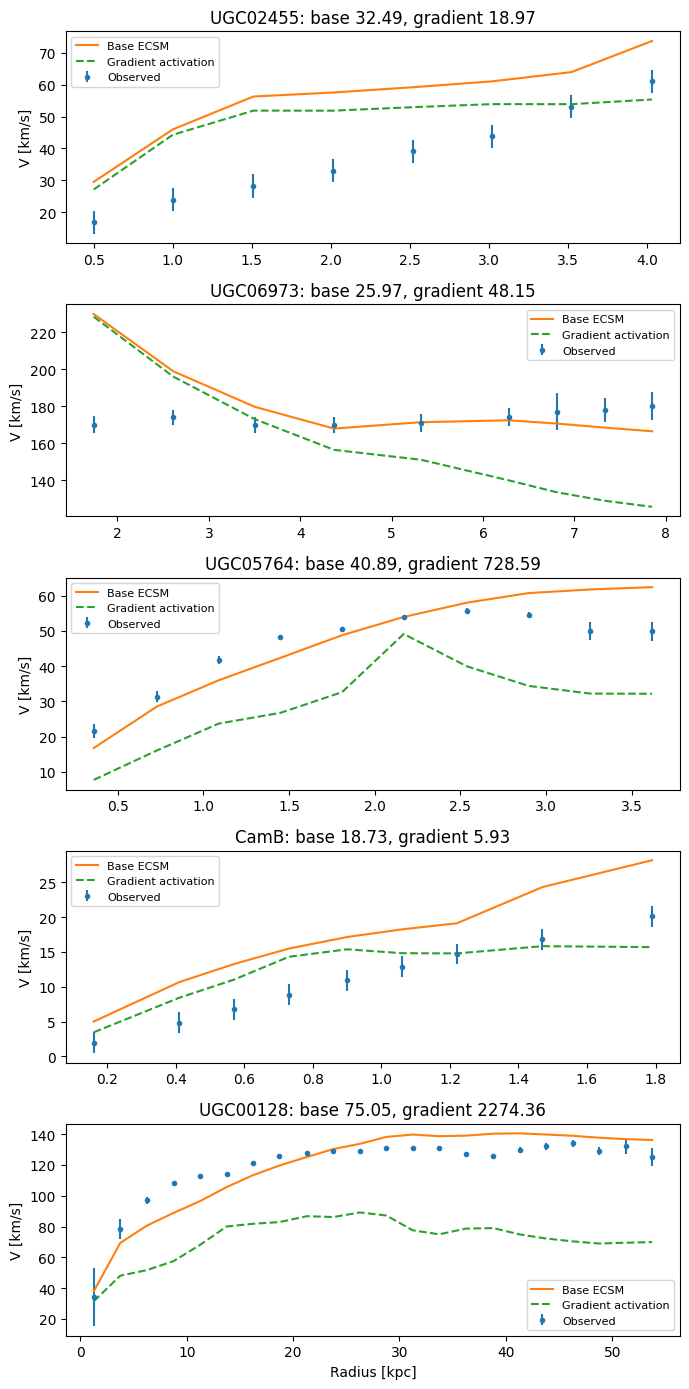

Saved:
/content/data/bad_galaxy_gradient_activation_summary.csv
/content/figures/bad_galaxy_gradient_activation_interpretation.png


In [ ]:

# ============================================================
# CELL 12 — GRADIENT-DERIVED ACTIVATION DIAGNOSTIC
# ============================================================

grad_rows = []
grad_curves = []

for gal in worst:
    g = curves[curves["galaxy"] == gal].copy().sort_values("Rad")
    r = g["Rad"].values
    vobs = g["Vobs"].values
    err = g["errV"].values
    vbar2 = g["Vbar"].values**2
    vbase2 = g["Vmodel"].values**2
    excess = np.clip(vbase2 - vbar2, 0, None)

    gbar = acceleration_from_v2_r(vbar2, r)
    log_r = np.log(np.clip(r, 1e-9, None))
    log_g = np.log(np.clip(gbar, 1e-30, None))
    D = np.abs(np.gradient(log_g, log_r))
    D_norm = (D - np.nanmin(D)) / max(np.nanmax(D) - np.nanmin(D), 1e-12)

    base_red, _, _ = red_chi2(vobs, g["Vmodel"].values, err, n_params=1)

    A_gradient = 1.0 / (1.0 + 5.0 * D_norm)
    outer_recovery = 0.5 + 0.5 * (r / max(np.nanmax(r), 1e-9))
    activation = np.clip(A_gradient * outer_recovery, 0.05, 1.0)

    vgrad = np.sqrt(np.clip(vbar2 + activation * excess, 0, None))
    grad_red, _, _ = red_chi2(vobs, vgrad, err, n_params=1)

    raw_val = summary.loc[summary["galaxy"] == gal, "chi2_raw_chi_mond"].iloc[0]

    grad_rows.append({
        "galaxy": gal,
        "N": len(g),
        "base_red_chi2": base_red,
        "raw_red_chi2": float(raw_val),
        "gradient_red_chi2": grad_red,
        "improvement_vs_base": base_red - grad_red,
        "improvement_vs_raw": float(raw_val) - grad_red,
        "median_D_gradient": float(np.nanmedian(D)),
        "median_D_norm": float(np.nanmedian(D_norm)),
        "median_A_gradient": float(np.nanmedian(activation)),
        "outer_A_gradient": float(np.nanmedian(activation[r >= np.median(r)])),
    })

    gc = g.copy()
    gc["Vgradient"] = vgrad
    gc["D_norm"] = D_norm
    gc["A_gradient"] = activation
    grad_curves.append(gc)

gradient_df = pd.DataFrame(grad_rows)
gradient_curves = pd.concat(grad_curves, ignore_index=True)

grad_path = DATA_DIR / "bad_galaxy_gradient_activation_summary.csv"
grad_curves_path = DATA_DIR / "bad_galaxy_gradient_activation_curves.csv"
gradient_df.to_csv(grad_path, index=False)
gradient_curves.to_csv(grad_curves_path, index=False)

print("=" * 70)
print("GRADIENT-DERIVED ACTIVATION DIAGNOSTIC")
print("=" * 70)
print("Fraction improved:", (gradient_df["improvement_vs_base"] > 0).mean())
print("Median improvement:", gradient_df["improvement_vs_base"].median())
display(gradient_df)

fig, axes = plt.subplots(len(worst), 1, figsize=(7, 2.8*len(worst)), sharex=False)
if len(worst) == 1:
    axes = [axes]

for ax, gal in zip(axes, worst):
    g = gradient_curves[gradient_curves["galaxy"] == gal].sort_values("Rad")
    ax.errorbar(g["Rad"], g["Vobs"], yerr=g["errV"], fmt="o", markersize=3, label="Observed")
    ax.plot(g["Rad"], g["Vmodel"], label="Base ECSM")
    ax.plot(g["Rad"], g["Vgradient"], linestyle="--", label="Gradient activation")
    row = gradient_df[gradient_df["galaxy"] == gal].iloc[0]
    ax.set_title(f"{gal}: base {row.base_red_chi2:.2f}, gradient {row.gradient_red_chi2:.2f}")
    ax.set_ylabel("V [km/s]")
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Radius [kpc]")
plt.tight_layout()
fig_path = FIGDIR / "bad_galaxy_gradient_activation_interpretation.png"
plt.savefig(fig_path, dpi=220)
plt.show()

print("Saved:")
print(grad_path)
print(fig_path)


In [ ]:

# ============================================================
# CELL 13 — EXPORT PAPER PACKAGE
# ============================================================

latex_metrics_path = DATA_DIR / "paper_metrics_table.tex"
global_accel_metrics.to_latex(latex_metrics_path, index=False, float_format="%.6f")

note = (
    "ECSM SPARC full-model reproduction notebook.\n\n"
    "This notebook starts from raw SPARC Rotmod_LTG.zip files, fits a finite-response ECSM\n"
    "rotation-curve model galaxy by galaxy, and regenerates the processed paper CSVs and figures.\n\n"
    "Key outputs:\n"
    f"- {summary_path}\n"
    f"- {curves_path}\n"
    f"- {DATA_DIR / 'paper_metrics_summary.csv'}\n"
    f"- {DATA_DIR / 'global_acceleration_metrics.csv'}\n"
    f"- {DATA_DIR / 'galaxy_level_acceleration_metrics.csv'}\n"
    f"- {FIGDIR / 'ecsm_full_sample_fit_quality.png'}\n"
    f"- {FIGDIR / 'ecsm_mond_acceleration_relation.png'}\n"
    f"- {FIGDIR / 'ecsm_response_factor_vs_gbar.png'}\n"
    f"- {FIGDIR / 'outer_memory_diagnostic_interpretation.png'}\n"
    f"- {FIGDIR / 'bad_galaxy_gradient_activation_interpretation.png'}\n"
    f"- {FIGDIR / 'bad_galaxy_abnormality_histograms.png'}\n\n"
    "Main full-sample metrics:\n"
    f"{metrics_df.to_string(index=False)}\n\n"
    "Global acceleration metrics:\n"
    f"{global_accel_metrics.to_string(index=False)}\n"
)

note_path = OUTDIR / "ecsm_sparc_full_model_reproduction_note.txt"
with open(note_path, "w") as f:
    f.write(note)

zip_path = ROOT / "ecsm_sparc_full_model_paper_outputs.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for folder in [DATA_DIR, FIGDIR, OUTDIR]:
        for p in folder.glob("**/*"):
            if p.is_file():
                z.write(p, arcname=str(p.relative_to(ROOT)))

print("=" * 70)
print("EXPORT COMPLETE")
print("=" * 70)
print("LaTeX metrics:", latex_metrics_path)
print("Note:", note_path)
print("Zip:", zip_path)


EXPORT COMPLETE
LaTeX metrics: /content/data/paper_metrics_table.tex
Note: /content/ecsm_sparc_full_model_outputs/ecsm_sparc_full_model_reproduction_note.txt
Zip: /content/ecsm_sparc_full_model_paper_outputs.zip
